In [2]:
!pip install transformers torch underthesea vncorenlp
!pip install transformers
!pip install torch torchvision

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 20.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 118.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 78.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.9/20.9 MB 78.5 MB/s eta 0:00:00
   

In [3]:
import re
import torch
from transformers import AutoTokenizer
from underthesea import word_tokenize

import pandas as pd
import requests
from torch.utils.data import DataLoader
from torch.utils.data import Dataset
from transformers import AutoTokenizer, AutoModel, BertForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [39]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [59]:
# Đọc file pkl vào DataFrame
df_train = pd.read_pickle("/content/drive/MyDrive/THT-2025/Train/dataset.pkl")
df_train = pd.DataFrame(df_train)

In [60]:
df_X = df_train["free_text"]
df_X = pd.DataFrame(df_X, columns=["free_text"])
df_X.head(10)

,free_text
0,"Xin chào, các bạn."
1,Mày muốn bị đấm không?
2,Tôi rất buồn vì sự việc này.
3,"Sắp nổ súng, ngươi hãy tránh xa!"
4,"Mặc kệ mày đi, không quan tâm."
5,"Đụ má, tao không tha cho mày đâu!"
6,Hãy thư giãn và sống vui vẻ.
7,"Nếu mày không nghe lời tao, tao sẽ đánh mày!"
8,Cùng nhau xây dựng một cộng đồng tốt đẹp.
9,"Mày hãy chịu, tao sẽ cho mày mũi đánh!"


In [61]:
df_y = df_train["label_id"]
df_y = pd.DataFrame(df_y, columns=["label_id"])
df_y.head(10)

,label_id
0,0
1,2
2,0
3,2
4,0
5,2
6,0
7,2
8,0
9,2


In [62]:
url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
stopwords = requests.get(url).text.splitlines()
vietnamese_stopwords = set(stopwords)

In [63]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)

In [64]:
# Hàm loại bỏ emoji
def de_emojify(text):
    emoji_pattern = re.compile(
        "["
        u"\U0001F600-\U0001F64F"  # emoticons
        u"\U0001F300-\U0001F5FF"  # symbols & pictographs
        u"\U0001F680-\U0001F6FF"  # transport & map symbols
        u"\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "]+", flags=re.UNICODE
    )
    return emoji_pattern.sub(r'', text)

# Tiền xử lý văn bản
def preprocess_text(text, stopwords, lowercased=True, remove_special_chars=True, min_word_count=1):
    """
    Tiền xử lý văn bản:
    - Loại bỏ emoji
    - Chuyển về chữ thường (nếu yêu cầu)
    - Loại bỏ ký tự đặc biệt
    - Tách từ và loại bỏ stopwords
    - Bỏ câu quá ngắn
    """
    # Loại bỏ emoji
    text = de_emojify(text)

    # Chuyển về chữ thường nếu yêu cầu
    if lowercased:
        text = text.lower()

    # Loại bỏ ký tự đặc biệt nếu yêu cầu
    if remove_special_chars:
        text = re.sub(r"[^a-zA-Záàảãạăắằẳẵặâấầẩẫậđéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵ ]+", " ", text)
        text = re.sub(r"\s+", " ", text).strip()

    # Tách từ
    tokens = word_tokenize(text, format="text").split()

    # Kiểm tra nếu số từ trong câu đủ lớn
    if len(tokens) < min_word_count:
        return None  # Bỏ qua câu quá ngắn

    # Loại bỏ stopwords
    filtered_tokens = [word for word in tokens if word not in stopwords]

    # Nối lại thành chuỗi
    return " ".join(filtered_tokens)

In [65]:
def encode_text(text, tokenizer, stopwords, min_word_count=1):
    """
    Tiền xử lý và mã hóa văn bản thành token IDs.
    """
    # Kiểm tra nếu text không phải là chuỗi
    if not isinstance(text, str):
        return None  # Trả về None nếu không phải chuỗi

    # Tiền xử lý văn bản
    processed_text = preprocess_text(text, stopwords, min_word_count=min_word_count)

    # Nếu câu quá ngắn, trả về None
    if processed_text is None or len(processed_text.split()) < min_word_count:
        return None

    # Mã hóa văn bản thành token IDs
    encoded = tokenizer(
        processed_text,
        padding="max_length",
        truncation=True,
        max_length=50,
        return_tensors="pt"
    )

    return {
        'input_ids': encoded['input_ids'].squeeze(0),
        'attention_mask': encoded['attention_mask'].squeeze(0),
        'token_type_ids': encoded.get('token_type_ids', None).squeeze(0) if 'token_type_ids' in encoded else None
    }

In [66]:
df_X['encoded_X'] = df_X['free_text'].apply(lambda x: encode_text(x, tokenizer, vietnamese_stopwords))
df_X = df_X.dropna(subset=['encoded_X'])
df_X.head(10)

,free_text,encoded_X
0,"Xin chào, các bạn.","{'input_ids': [tensor(0), tensor(3683), tensor..."
1,Mày muốn bị đấm không?,"{'input_ids': [tensor(0), tensor(5262), tensor..."
2,Tôi rất buồn vì sự việc này.,"{'input_ids': [tensor(0), tensor(1520), tensor..."
3,"Sắp nổ súng, ngươi hãy tránh xa!","{'input_ids': [tensor(0), tensor(33379), tenso..."
4,"Mặc kệ mày đi, không quan tâm.","{'input_ids': [tensor(0), tensor(1036), tensor..."
5,"Đụ má, tao không tha cho mày đâu!","{'input_ids': [tensor(0), tensor(3438), tensor..."
6,Hãy thư giãn và sống vui vẻ.,"{'input_ids': [tensor(0), tensor(4583), tensor..."
7,"Nếu mày không nghe lời tao, tao sẽ đánh mày!","{'input_ids': [tensor(0), tensor(5262), tensor..."
8,Cùng nhau xây dựng một cộng đồng tốt đẹp.,"{'input_ids': [tensor(0), tensor(141), tensor(..."
9,"Mày hãy chịu, tao sẽ cho mày mũi đánh!","{'input_ids': [tensor(0), tensor(5262), tensor..."


In [67]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base", use_fast=False)
# Tạo mô hình phân loại từ PhoBERT với 3 nhãn
model = BertForSequenceClassification.from_pretrained("vinai/phobert-base", num_labels=3)

You are using a model of type roberta to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base and are newly initialized: ['bert.embeddings.LayerNorm.bias', 'bert.embeddings.LayerNorm.weight', 'bert.embeddings.position_embeddings.weight', 'bert.embeddings.token_type_embeddings.weight', 'bert.embeddings.word_embeddings.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.dense.bias', 'bert.encoder.layer.0.attention.output.dense.weight', 'bert.encoder.layer.0.attention.self.key.bias', 'bert.encoder.layer.0.attention.self.key.weight', 'bert.encoder.layer.0.attention.self.query.bias', 'bert.encoder.layer.0.attention.self.query.weight', 'bert.encoder.layer.0.attention.self.value.bias', 'bert.encoder.layer.0.attenti

In [70]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [71]:
epochs = 10
batch_size= 4
learning_rate = 1e-5

In [72]:
df = pd.DataFrame()
df['encoded_X'] = df_X['encoded_X'].tolist()
df['label'] = df_y['label_id']

In [73]:
# Dataset tùy chỉnh
class ViolenceDataset(Dataset):
    def __init__(self, df, device): # Add device as an argument
        self.encodings = df['encoded_X'].tolist()
        self.labels = df['label'].tolist()
        self.device = device

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoding = self.encodings[idx]

        item = {
            'input_ids': torch.tensor(encoding['input_ids']).squeeze(0).to(self.device),
            'attention_mask': torch.tensor(encoding['attention_mask']).squeeze(0).to(self.device),
            'labels': torch.tensor(self.labels[idx]).to(self.device)
        }
        return item

# Tạo dataset và dataloader
dataset = ViolenceDataset(df, device)
train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [74]:
df.head(10)

,encoded_X,label
0,"{'input_ids': [tensor(0), tensor(3683), tensor...",0
1,"{'input_ids': [tensor(0), tensor(5262), tensor...",2
2,"{'input_ids': [tensor(0), tensor(1520), tensor...",0
3,"{'input_ids': [tensor(0), tensor(33379), tenso...",2
4,"{'input_ids': [tensor(0), tensor(1036), tensor...",0
5,"{'input_ids': [tensor(0), tensor(3438), tensor...",2
6,"{'input_ids': [tensor(0), tensor(4583), tensor...",0
7,"{'input_ids': [tensor(0), tensor(5262), tensor...",2
8,"{'input_ids': [tensor(0), tensor(141), tensor(...",0
9,"{'input_ids': [tensor(0), tensor(5262), tensor...",2


In [75]:
# Khởi tạo các danh sách để lưu trữ loss và accuracy
train_losses = []
test_losses = []
accuracies = []

optimizer = AdamW(model.parameters(), lr=learning_rate)
model.to(device)
model.train()

# Hàm tính accuracy
def compute_accuracy(predictions, labels):
    preds = torch.argmax(predictions, dim=1)
    return accuracy_score(labels.cpu().numpy(), preds.cpu().numpy())

Epoch 1/10


  0%|          | 0/10 [00:00<?, ?it/s]<ipython-input-73-417e75e3d5e9>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(encoding['input_ids']).squeeze(0).to(self.device),
<ipython-input-73-417e75e3d5e9>:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(encoding['attention_mask']).squeeze(0).to(self.device),
100%|██████████| 10/10 [00:00<00:00, 11.87it/s]


Train Loss: 0.9133, Accuracy: 0.6250
Epoch 2/10


  0%|          | 0/10 [00:00<?, ?it/s]<ipython-input-73-417e75e3d5e9>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(encoding['input_ids']).squeeze(0).to(self.device),
<ipython-input-73-417e75e3d5e9>:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(encoding['attention_mask']).squeeze(0).to(self.device),
100%|██████████| 10/10 [00:00<00:00, 12.65it/s]


Train Loss: 0.8491, Accuracy: 0.6750
Epoch 3/10


...

Train Loss: 0.4132, Accuracy: 0.8500
Epoch 9/10


  0%|          | 0/10 [00:00<?, ?it/s]<ipython-input-73-417e75e3d5e9>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(encoding['input_ids']).squeeze(0).to(self.device),
<ipython-input-73-417e75e3d5e9>:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(encoding['attention_mask']).squeeze(0).to(self.device),
100%|██████████| 10/10 [00:00<00:00, 11.40it/s]


Train Loss: 0.3321, Accuracy: 0.9000
Epoch 10/10


  0%|          | 0/10 [00:00<?, ?it/s]<ipython-input-73-417e75e3d5e9>:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'input_ids': torch.tensor(encoding['input_ids']).squeeze(0).to(self.device),
<ipython-input-73-417e75e3d5e9>:16: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  'attention_mask': torch.tensor(encoding['attention_mask']).squeeze(0).to(self.device),
100%|██████████| 10/10 [00:00<00:00, 12.62it/s]


Train Loss: 0.3153, Accuracy: 0.8750


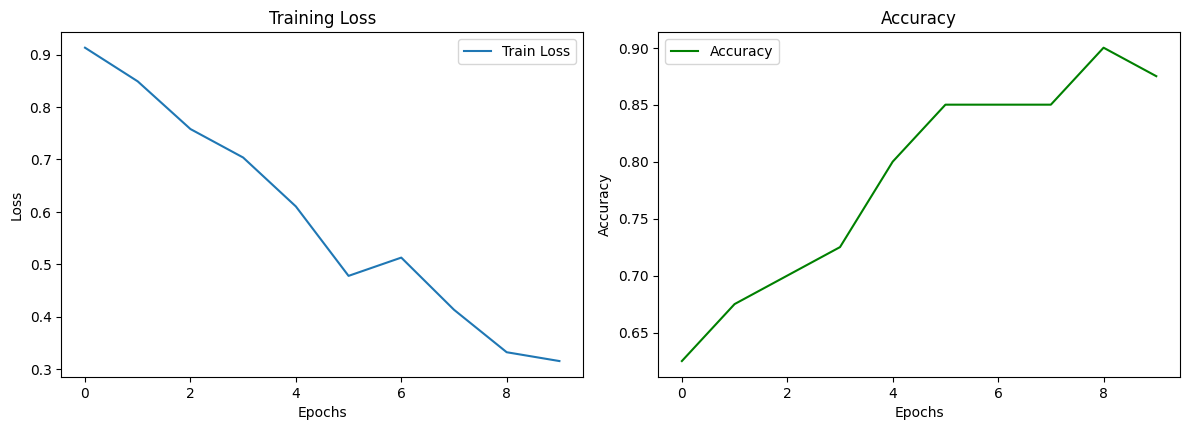

In [76]:
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")
    total_train_loss = 0
    all_preds = []
    all_labels = []

    for batch in tqdm(train_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss
        total_train_loss += loss.item()

        # Backward pass
        loss.backward()
        optimizer.step()

        # Collect predictions and labels for accuracy
        logits = outputs.logits
        all_preds.append(logits)
        all_labels.append(labels)

    # Tính toán accuracy
    all_preds = torch.cat(all_preds, dim=0)
    all_labels = torch.cat(all_labels, dim=0)
    accuracy = compute_accuracy(all_preds, all_labels)

    # Tính trung bình train loss cho epoch
    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    accuracies.append(accuracy)

    print(f"Train Loss: {avg_train_loss:.4f}, Accuracy: {accuracy:.4f}")


# Vẽ biểu đồ
plt.figure(figsize=(12, 8))

# Train Loss
plt.subplot(2, 2, 1)
plt.plot(range(epochs), train_losses, label='Train Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()

# Accuracy
plt.subplot(2, 2, 2)
plt.plot(range(epochs), accuracies, label='Accuracy', color='green')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Accuracy')
plt.legend()


plt.tight_layout()
plt.show()


In [20]:
model.save_pretrained("model")
tokenizer.save_pretrained("model")

('model/tokenizer_config.json',
 'model/special_tokens_map.json',
 'model/vocab.txt',
 'model/bpe.codes',
 'model/added_tokens.json')

In [21]:
model = BertForSequenceClassification.from_pretrained("model")
tokenizer = AutoTokenizer.from_pretrained("model")

In [22]:
def predict_violence_level(text, model, tokenizer):
    model.eval()
    model.to(device)

    # Tiền xử lý văn bản như khi train
    text = preprocess_text(text, stopwords)
    encoding = tokenizer(text, return_tensors="pt", padding="max_length", truncation=True, max_length=50)
    encoding = {key: val.to(device) for key, val in encoding.items()}

    # Dự đoán
    with torch.no_grad():
        outputs = model(**encoding)
        logits = outputs.logits
        predicted_class = torch.argmax(logits, dim=1).item()

    label_map = {0: "low", 1: "medium", 2: "high"}
    return label_map[predicted_class]

In [23]:
sample = "Tao sẽ đánh mày ngay bây giờ!"
print(predict_violence_level(sample, model, tokenizer))

high


In [24]:
import shutil

# Nén thư mục chứa mô hình và tokenizer
shutil.make_archive("/content/model", 'zip', "/content", "model")

'/content/model.zip'

In [25]:
from google.colab import files

# Tải file zip về máy tính
files.download("/content/model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>